CELL 1 — Imports

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import (
    butter,
    filtfilt,
    medfilt
)

from scipy.stats import (
    zscore,
    linregress
)

CELL 2 — Load WESAD Subject File

In [2]:
with open("../data/raw/WESAD/S2/S2.pkl", "rb") as f:
    data = pickle.load(
        f,
        encoding="latin1"
    )

print("Data loaded successfully.")

Data loaded successfully.


CELL 3 — Extract Signals + Define Sampling Rates

In [3]:
# ==========================
# WRIST SIGNALS
# ==========================

wrist_eda = data['signal']['wrist']['EDA'].flatten()

wrist_temp = data['signal']['wrist']['TEMP'].flatten()
 
wrist_acc = data['signal']['wrist']['ACC']


# ==========================
# CHEST SIGNALS
# ==========================

chest_eda = data['signal']['chest']['EDA'].flatten()

chest_temp = data['signal']['chest']['Temp'].flatten()

chest_acc = data['signal']['chest']['ACC']


# ==========================
# SAMPLING RATES
# ==========================

fs_wrist_eda = 4
fs_wrist_temp = 4
 
fs_wrist_acc = 32

fs_chest_eda = 700
fs_chest_temp = 700
fs_chest_acc = 700


# ==========================
# CHECK SIGNAL SHAPES
# ==========================

print("WRIST EDA :", wrist_eda.shape)
print("WRIST TEMP:", wrist_temp.shape)

print("CHEST EDA :", chest_eda.shape)
print("CHEST TEMP:", chest_temp.shape)


WRIST EDA : (24316,)
WRIST TEMP: (24316,)
CHEST EDA : (4255300,)
CHEST TEMP: (4255300,)


In [4]:
from scipy.signal import butter, filtfilt

# -----------------------
# EDA Filter Function
# -----------------------

def filter_eda(signal, fs, cutoff=0.2, order=4):

    nyquist = fs / 2

    b, a = butter(
        order,
        cutoff / nyquist,
        btype='low'
    )

    return filtfilt(b, a, signal)

# -----------------------
# Create Filtered Signals
# -----------------------

wrist_eda_filtered = filter_eda(
    wrist_eda,
    fs=4
)

chest_eda_filtered = filter_eda(
    chest_eda,
    fs=700
)

print("Wrist Filtered Shape:", wrist_eda_filtered.shape)
print("Chest Filtered Shape:", chest_eda_filtered.shape)

Wrist Filtered Shape: (24316,)
Chest Filtered Shape: (4255300,)


Step 2: Create a General Window Function

In [5]:
def create_windows(signal, fs, window_size=5):

    samples_per_window = int(fs * window_size)

    windows = []

    for start in range(
        0,
        len(signal) - samples_per_window + 1,
        samples_per_window
    ):

        end = start + samples_per_window

        windows.append(signal[start:end])

    return np.array(windows)

Step 3: Create 5-Second Windows
Wrist EDA

In [6]:
wrist_windows = create_windows(
    wrist_eda_filtered,
    fs=4,
    window_size=5
)

print(wrist_windows.shape)

(1215, 20)


Chest EDA

In [7]:
chest_windows = create_windows(
    chest_eda_filtered,
    fs=700,
    window_size=5
)

print(chest_windows.shape)

(1215, 3500)


Step 4: Visualize First Few Windows

Wrist

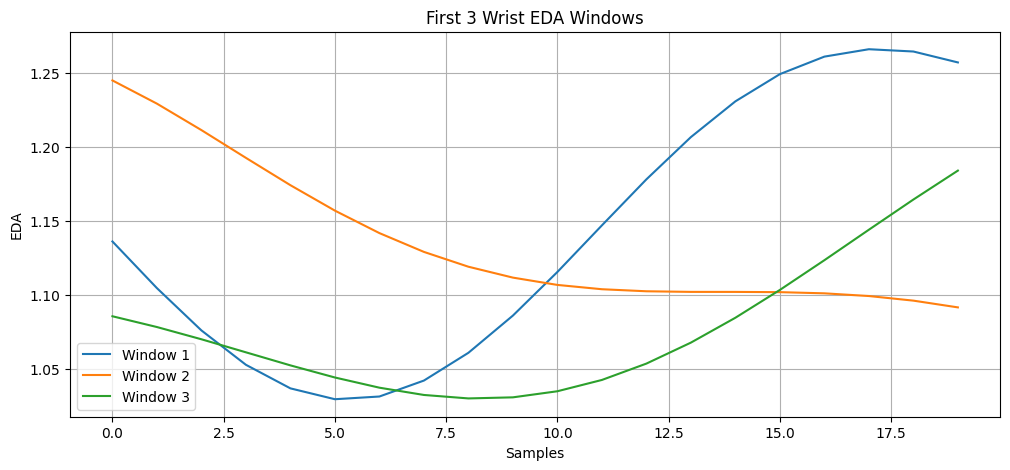

In [8]:
plt.figure(figsize=(12,5))

for i in range(3):
    plt.plot(
        wrist_windows[i],
        label=f"Window {i+1}"
    )

plt.title("First 3 Wrist EDA Windows")

plt.xlabel("Samples")
plt.ylabel("EDA")

plt.legend()
plt.grid()

plt.show()

Chest

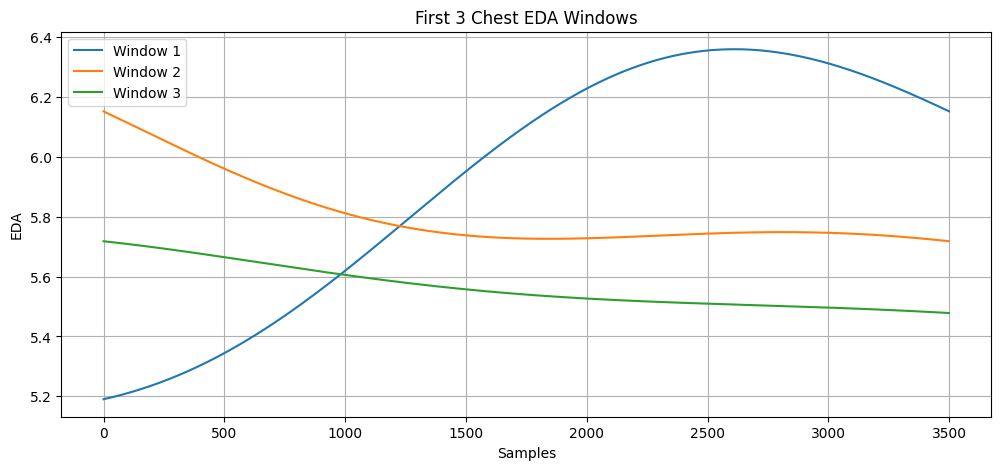

In [9]:
plt.figure(figsize=(12,5))

for i in range(3):
    plt.plot(
        chest_windows[i],
        label=f"Window {i+1}"
    )

plt.title("First 3 Chest EDA Windows")

plt.xlabel("Samples")
plt.ylabel("EDA")

plt.legend()
plt.grid()

plt.show()

Step 5: Overlapping Windows (Recommended)

Most stress-detection papers use overlap.

In [10]:
def create_overlap_windows(
        signal,
        fs,
        window_size=5,
        overlap=0.5):

    window_samples = int(fs * window_size)

    step = int(
        window_samples * (1-overlap)
    )

    windows = []

    for start in range(
        0,
        len(signal)-window_samples+1,
        step
    ):

        end = start + window_samples

        windows.append(signal[start:end])

    return np.array(windows)

In [11]:
wrist_windows = create_overlap_windows(
    wrist_eda_filtered,
    fs=4,
    window_size=5,
    overlap=0.5
)

print(wrist_windows.shape)

(2430, 20)


Step 6: Extract Features from Each Window

In [12]:
features = []

for window in wrist_windows:

    features.append([
        np.mean(window),
        np.std(window),
        np.min(window),
        np.max(window)
    ])

features = np.array(features)

print(features.shape)

(2430, 4)
